In [2]:
import pandas as pd
df = pd.read_csv("final2055.csv")
print("Data upload success!")
df.head()

Data upload success!


,page_link,page_id,query_time,post_id,post_created_time,post,comment_created_time,comment,sentiment
0,https://www.facebook.com/jhumurskitchen/,1.053349e+14,2023-05-07 9:10:28,105334900956006_782720089884147,2023-05-04T16:44:38+0000,🎀আমড়া দিয়ে মুরগি ভুনা🎀 ........রেসিপি...... উপ...,2023-05-05T05:02:13+0000,Morchi,N
1,https://www.facebook.com/jhumurskitchen/,1.053349e+14,2023-05-07 9:10:28,105334900956006_782719213217568,2023-05-04T16:42:54+0000,🎀সজনে ডাটায় লইট্যা শুটকি ভুনা🎀 .......রেসিপি.....,2023-05-06T18:45:46+0000,Onek mojar khabar,P
2,https://www.facebook.com/jhumurskitchen/,1.053349e+14,2023-05-07 9:10:28,105334900956006_782718369884319,2023-05-04T16:41:22+0000,🎀ডিমের সালাদ🎀 .......রেসিপি........ ডিমের সাল...,2023-05-05T03:16:48+0000,🥰🥰🥰❤️❤️❤️,P
3,https://www.facebook.com/jhumurskitchen/,1.053349e+14,2023-05-07 9:10:28,105334900956006_782718369884319,2023-05-04T16:41:22+0000,🎀ডিমের সালাদ🎀 .......রেসিপি........ ডিমের সাল...,2023-05-05T04:02:08+0000,👍😍,P
4,https://www.facebook.com/jhumurskitchen/,1.053349e+14,2023-05-07 9:10:28,105334900956006_782717199884436,2023-05-04T16:39:10+0000,🎀কাঁচা আমের টক ঝাল মিস্টি জুস/শরবত🎀 .....রেসিপ...,2023-05-05T04:37:15+0000,😋😋😋😋,P


In [3]:
!pip install emoji

import pandas as pd
import emoji
import re
from IPython.display import display

df = pd.read_csv("final2055.csv")
df = df[['comment', 'sentiment']].dropna()

def clean_text(text):
    if not isinstance(text, str):
        return ""
        
    # emoji → words (important for sentiment)
    text = emoji.demojize(text, delimiters=(" ", " "))
    
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # keep ! ? because they carry sentiment
    text = re.sub(r'[^\w\s!?]', '', text)
    
    # remove numbers
    text = re.sub(r'[0-9০-৯]+', '', text)
    
    # normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


df = df.drop_duplicates()


df['cleaned_comment'] = df['comment'].apply(clean_text)
df = df[df['cleaned_comment'].str.len() > 1]
df['cleaned_comment'] = df['cleaned_comment'].apply(lambda x: re.sub(r'(.)\1{2,}', r'\1\1', x))
display(df[['comment', 'cleaned_comment', 'sentiment']].head(10))


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])
print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts(normalize=True))



Defaulting to user installation because normal site-packages is not writeable


,comment,cleaned_comment,sentiment
0,Morchi,morchi,N
1,Onek mojar khabar,onek mojar khabar,P
2,🥰🥰🥰❤️❤️❤️,smiling_face_with_hearts smiling_face_with_hea...,P
3,👍😍,thumbs_up smiling_face_with_hearteyes,P
4,😋😋😋😋,face_savoring_food face_savoring_food face_sav...,P
5,Ami to pani na die dod dei r khete o onek moja...,ami to pani na die dod dei r khete o onek moja...,P
6,Apu achar a Tel onkk kom oity ki Tel dibo...?...,apu achar a tel onkk kom oity ki tel dibo? tel...,NEU
7,👍👍👍,thumbs_up thumbs_up thumbs_up,P
8,Apu apnar recipe daowar style onek sundor.tai ...,apu apnar recipe daowar style onek sundortai b...,P
9,Apnar recipe gula onek sundor.♥️♥️,apnar recipe gula onek sundor heart_suit heart...,P


sentiment
NEU    881
P      589
N      548
Name: count, dtype: int64
sentiment
NEU    0.436571
P      0.291873
N      0.271556
Name: proportion, dtype: float64


In [4]:
print("Total number of comments:", len(df))

Total number of comments: 2018


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

X = df['cleaned_comment']
y = df['sentiment_encoded']

word_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    analyzer='word'
)

char_vectorizer = TfidfVectorizer(
    max_features=5000,
    analyzer='char_wb',
    ngram_range=(2,5)
)

# Fit both
X_word = word_vectorizer.fit_transform(X)
X_char = char_vectorizer.fit_transform(X)

# Combine
X_vectorized = hstack([X_word, X_char])


X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Advanced Character-level TF-IDF Vectorization Successful!")
print(f"Shape: {X_vectorized.shape}")

Advanced Character-level TF-IDF Vectorization Successful!
Shape: (2018, 10000)


In [6]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

models = {
    "Support Vector Machine (SVM)": LinearSVC(C=10, class_weight='balanced', max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression(C=5, class_weight='balanced', max_iter=2000, random_state=42),
    "Naive Bayes (Text Specialist)": MultinomialNB(alpha=0.1)
}
print("--- Advanced Model Accuracy Results ---\n")

best_model_name = ""
best_accuracy = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc * 100:.2f}%")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name

print(f"\nbest model: {best_model_name} with {best_accuracy * 100:.2f}%")

--- Advanced Model Accuracy Results ---

Support Vector Machine (SVM) Accuracy: 68.07%
Random Forest Accuracy: 67.82%
Logistic Regression Accuracy: 70.30%
Naive Bayes (Text Specialist) Accuracy: 66.34%

best model: Logistic Regression with 70.30%


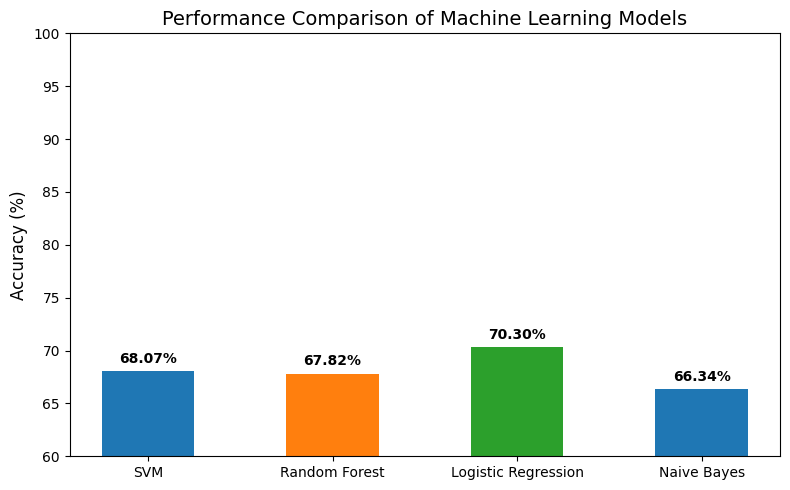

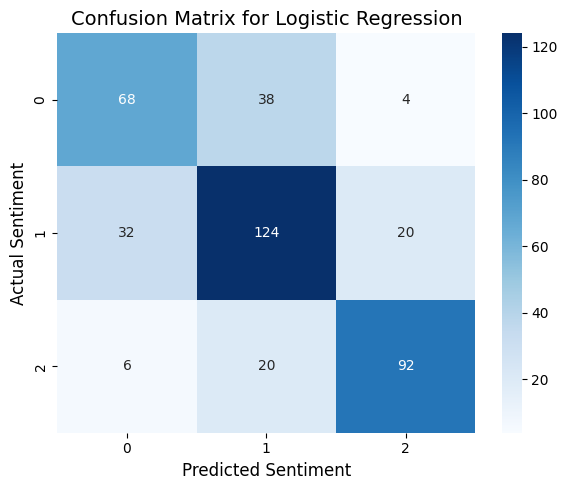

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model_names = []
accuracies = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracies.append(acc)
    if "SVM" in name:
        model_names.append("SVM")
    elif "Random" in name:
        model_names.append("Random Forest")
    elif "Naive" in name:
        model_names.append("Naive Bayes")
    else:
        model_names.append("Logistic Regression")

plt.figure(figsize=(8, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = plt.bar(model_names, accuracies, color=colors, width=0.5)
plt.ylim(60, 100)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Performance Comparison of Machine Learning Models', fontsize=14)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

LogisticRegression = models["Logistic Regression"]  
y_pred_svm = LogisticRegression.predict(X_test)
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LogisticRegression.classes_, yticklabels=LogisticRegression.classes_)
plt.xlabel('Predicted Sentiment', fontsize=12)
plt.ylabel('Actual Sentiment', fontsize=12)
plt.title('Confusion Matrix for Logistic Regression', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:


import pandas as pd
df = pd.read_csv("final2055.csv")
df = df[['comment', 'sentiment']].dropna()
print("Total count of each sentiment:")
print(df['sentiment'].value_counts())

Total count of each sentiment:
sentiment
NEU    887
P      609
N      559
Name: count, dtype: int64
